In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/fivemodal')

In [3]:
rna = sc.read('scRNA.h5ad')
spatial_coords = rna.obs[['x', 'y']].copy()
spatial_coords = spatial_coords.values

rna = sc.read('preprocessed_rna.h5ad')
rna_feat = rna.X.toarray() if scipy.sparse.issparse(rna.X) else rna.X

H3K27me3 = sc.read('preprocessed_H3K27me3.h5ad')
H3K27me3_feat = H3K27me3.obsm['X_lsi'][:, :1024]

atac = sc.read('preprocessed_atac.h5ad')
atac_feat = atac.obsm['X_lsi'][:, :1024]

H3K27ac = sc.read('preprocessed_H3K27ac.h5ad')
H3K27ac_feat = H3K27ac.obsm['X_lsi'][:, :1024]


protein = sc.read('preprocessed_protein.h5ad')
protein_feat = protein.X.toarray() if scipy.sparse.issparse(protein.X) else protein.X


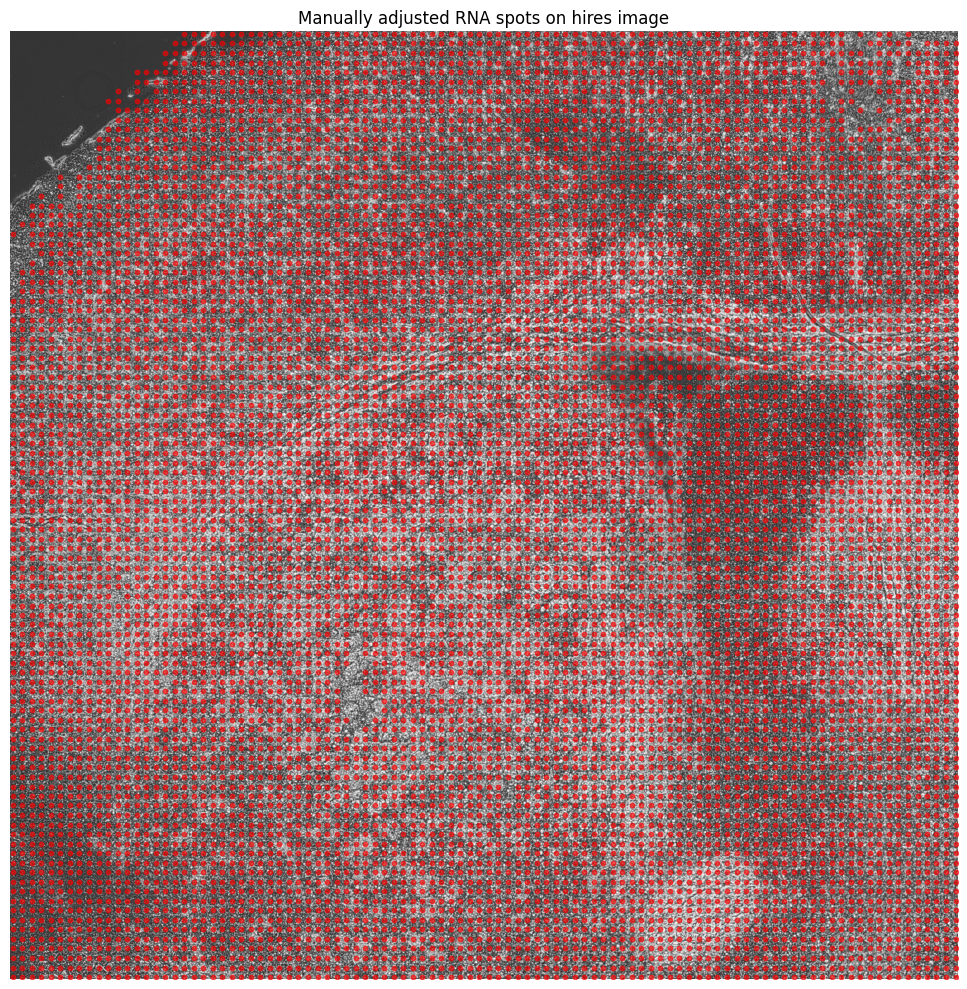

In [4]:
img = Image.open("5M_20um_RNA/spatial/tissue_lowres_image.png").convert("RGB")
img_np = np.array(img)

rna_coords = spatial_coords

manual_scale = 1  
manual_shift = np.array([0, 0]) 

coords_fullres = rna_coords  
coords_hires = (coords_fullres + manual_shift) * manual_scale

plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.scatter(coords_hires[:, 0], coords_hires[:, 1], s=10, c='red', alpha=0.6)
plt.title("Manually adjusted RNA spots on hires image")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from tqdm import tqdm

def extract_patch_safe(img, center_x, center_y, patch_size):
    h, w, _ = img.shape
    patch = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 255 

    half = patch_size // 2
    start_x = center_x - half
    start_y = center_y - half
    end_x = center_x + half
    end_y = center_y + half

    img_x1 = int(max(start_x, 0))
    img_x2 = int(min(end_x, w))
    img_y1 = int(max(start_y, 0))
    img_y2 = int(min(end_y, h))

    patch_x1 = int(img_x1 - start_x)
    patch_x2 = int(patch_x1 + (img_x2 - img_x1))
    patch_y1 = int(img_y1 - start_y)
    patch_y2 = int(patch_y1 + (img_y2 - img_y1))

    patch[patch_y1:patch_y2, patch_x1:patch_x2] = img[img_y1:img_y2, img_x1:img_x2]
    return patch

def extract_embeddings_batch_dualscale(
    img,
    coords_img,
    patch_sizes=(24, 32),
    batch_size=128,
    device='cuda'
):

    import torch
    import numpy as np
    from PIL import Image
    from tqdm import tqdm
    from gsmo.hist_features_uni import model, transform

    if isinstance(img, Image.Image):
        img = np.array(img.convert("RGB"))

    model.eval()
    model.to(device)

    embeddings = []

    with torch.inference_mode():
        for i in tqdm(range(0, len(coords_img), batch_size), desc="Extracting dual-scale embeddings"):
            coords_batch = coords_img[i:i+batch_size]

            patches_small = [extract_patch_safe(img, int(x), int(y), patch_sizes[0]) for (x, y) in coords_batch]
            patches_large = [extract_patch_safe(img, int(x), int(y), patch_sizes[1]) for (x, y) in coords_batch]

            batch_s = torch.stack([transform(Image.fromarray(p)) for p in patches_small]).to(device)
            batch_l = torch.stack([transform(Image.fromarray(p)) for p in patches_large]).to(device)

            emb_s = model(batch_s).cpu().numpy()  # [B, 1536]
            emb_l = model(batch_l).cpu().numpy()  # [B, 1536]

            emb = np.concatenate([emb_s, emb_l], axis=1)  # [B, 3072]
            embeddings.append(emb)

    return np.concatenate(embeddings, axis=0)



embeddings = extract_embeddings_batch_dualscale(
    img=img,
    coords_img=coords_hires,
    patch_sizes=(24, 32),
    batch_size=256,
    device='cuda'
)

print("embedding shape:", embeddings.shape)  # [N, 3072]

np.save("img_embeddings.npy", embeddings)


Extracting dual-scale embeddings: 100%|██████████| 38/38 [08:26<00:00, 13.32s/it]

embedding shape: (9686, 3072)


In [5]:
from sklearn.preprocessing import StandardScaler


image_embeddings = np.load("img_embeddings.npy")  # [N, 1536]
assert image_embeddings.shape[0] == rna.shape[0]


In [ ]:
from gsmo import GSMOConfig
features_dict = {
        'rna': rna_feat,        
        'protein': protein_feat,     
        'atac': atac_feat,       
        'h3k27me3': H3K27me3_feat,    
        'h3k27ac': H3K27ac_feat,  
        'image': image_embeddings
    }

initial_weights = [5.0, 1.0, 1.0, 3.0, 1.0, 0.01] 


cfg = GSMOConfig

model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg,
            trainable_weights=False, initial_weights=initial_weights)

model.load_state_dict(torch.load("best_model_fig.pth"))

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

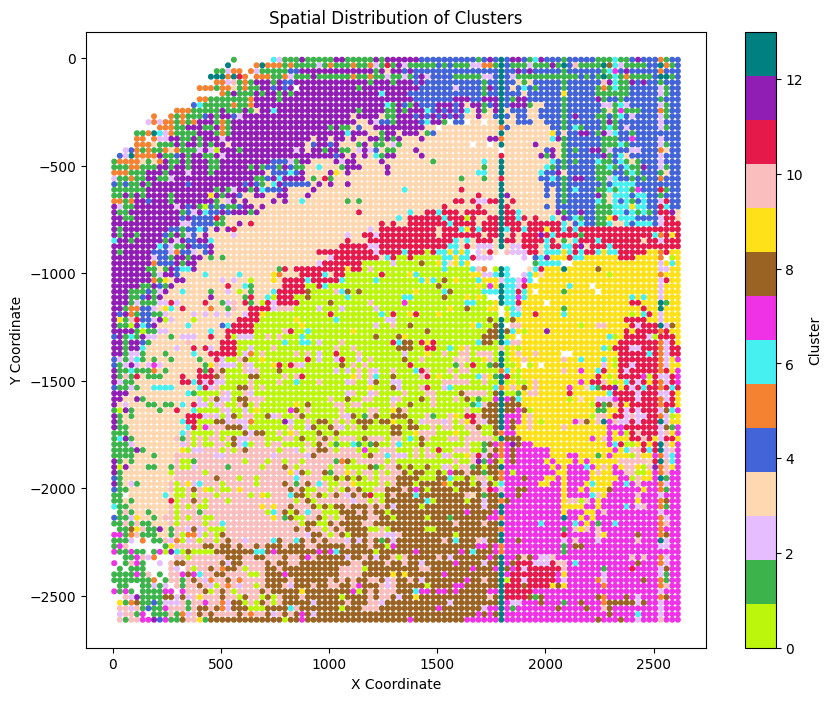

In [7]:
# visualization of clustering resullts
from matplotlib.colors import ListedColormap

plot_color = ['#bcf60c', '#3cb44b', '#e6beff', '#ffd8b1', '#4363d8', '#f58231', '#46f0f0', '#f032e6', 
              '#9a6324', '#ffe119', '#fabebe', '#e6194b', '#911eb4', '#008080', '#800000', '#aaffc3', '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1'] # '#4363d8'

rna = sc.read('scRNA.h5ad')


assert 'x' in rna.obs.columns and 'y' in rna.obs.columns, "The RNA data is missing spatial coordinates or has an incorrect format. Please check the data."
rna_locs = rna.obs[['x', 'y']].copy()


# rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "The RNA data is missing spatial coordinates or has an incorrect format. Please check the data."


clusters = model.cluster_kmeans(n_clusters=14)

rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  
rna_locs_df['cluster'] = clusters  

num_clusters = len(np.unique(clusters))

if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")

cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['y'], -rna_locs_df['x'], c=rna_locs_df['cluster'], cmap=cmap, s=11)
plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters")
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()



In [8]:
# two unsupervised metrics

from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):
    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq

def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result


fused_embeddings = model.get_embeddings()

jaccard_all, jaccard_mean = compute_jaccard_similarity(rna_feat, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(atac_feat, fused_embeddings, k=50)
print(f"Mean Jaccard atac Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K27me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K27me3 Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K27ac_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K27ac Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(protein_feat, fused_embeddings, k=50)
print(f"Mean Jaccard protein Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(image_embeddings, fused_embeddings, k=50)
print(f"Mean Jaccard image Similarity: {jaccard_mean:.4f}") 

cluster_labels = model.cluster_kmeans(n_clusters=14)
morans_I = compute_morans_I(cluster_labels, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1597.17it/s]


Mean Jaccard RNA Similarity: 0.0209


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1601.07it/s]


Mean Jaccard atac Similarity: 0.0087


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1609.44it/s]


...

Mean Jaccard H3K27ac Similarity: 0.0047


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1563.44it/s]


Mean Jaccard protein Similarity: 0.0488


Calculating Jaccard similarities: 100%|██████████| 9686/9686 [00:06<00:00, 1603.00it/s]


Mean Jaccard image Similarity: 0.0071
Moran's I score: 0.4045


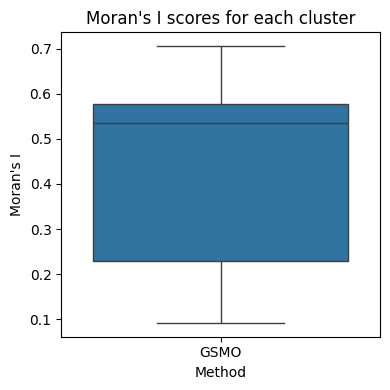

   cluster   moran_I method
0        0  0.533400   GSMO
1        1  0.285386   GSMO
2        2  0.092045   GSMO
3        3  0.705213   GSMO
4        4  0.538790   GSMO
5        5  0.209986   GSMO
6        6  0.127332   GSMO
7        7  0.658837   GSMO
8        8  0.535694   GSMO
9        9  0.632145   GSMO
10      10  0.369293   GSMO
11      11  0.534840   GSMO
12      12  0.590991   GSMO
13      13  0.194663   GSMO


In [9]:
# moran's I box plot

import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(clusters, spatial_coords, method_name="GSMO")
print(morans_I_df)


Raw expression: [-0.21457606 -0.21457606 -0.21457606 ... -0.21457606 -0.21457606
 -0.21457606]
Min: -0.21457605593497256 Max: 39.33018666401054


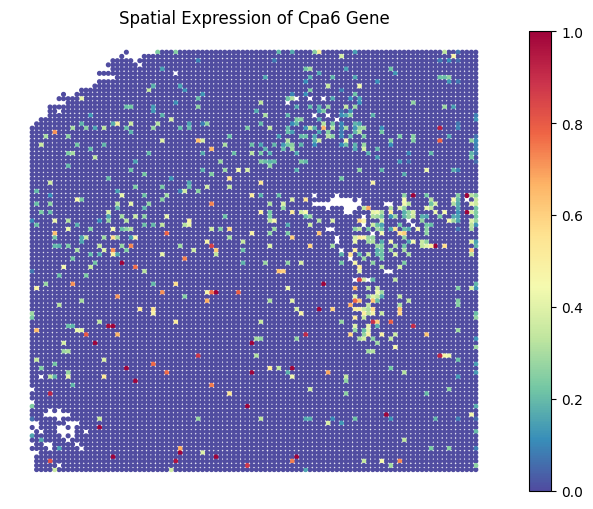

In [11]:
# heat map of expressions of selected genes
# mainly focus on Bcl11b、Cux2、Rorb、St18、Cpa6 genes
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    'my_cmap', ["#504ca0","#388fb9", "#74c7a4", "#c1e69f","#f5faaf","#fee391","#fdb466","#ef6545","#cb334c", "#9f033a"], N=256
)

rna = sc.read('scRNA.h5ad')
adata_p = rna
sc.pp.normalize_total(adata_p, target_sum=1e4) 
sc.pp.scale(adata_p, zero_center=True) 

if 'Cpa6' not in adata_p.var_names:
    print("The Cpa6 gene is not in the dataset. Please confirm if the Cpa6 gene exists in the data.")
else:
    cux1_expression = adata_p[:, 'Cpa6'].X.toarray().flatten()  
    print("Raw expression:", cux1_expression)
    print("Min:", cux1_expression.min(), "Max:", cux1_expression.max())

    cux1_expression_zscore = (cux1_expression - np.mean(cux1_expression)) / np.std(cux1_expression)

    scaled_cux1 = np.clip(cux1_expression_zscore, -5, 8) 
    scaled_cux1 = np.interp(scaled_cux1, (scaled_cux1.min(), scaled_cux1.max()), (0, 1))

    x = spatial_coords[:, 1]
    y = -spatial_coords[:, 0]

    plt.figure(figsize=(6.4, 5.2))
    scatter = plt.scatter(x, y, c=scaled_cux1, cmap=custom_cmap, s=7, alpha=1.0)
    plt.colorbar(scatter)
    plt.title("Spatial Expression of Cpa6 Gene")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
